In [ ]:
#ANALISI PER FONTE

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

df = pd.read_csv('Rinnovabili_Pulito:Mesi_2021_2026.csv')
fabbisogno = pd.read_csv('Fabbisogno_Energetico_Mensile.csv')

# Prepara fabbisogno in GWh
fabbisogno['Date'] = pd.to_datetime(fabbisogno['Date'])
fabbisogno['ore_mese'] = fabbisogno['Date'].dt.days_in_month * 24
fabbisogno['Fabbisogno_GWh'] = fabbisogno['Total Load [MW]'] * fabbisogno['ore_mese'] / 1000
fabbisogno['Date'] = fabbisogno['Date'].dt.strftime('%Y-%m')

df['Date'] = df['Date'].astype(str)

# Merge
df = pd.merge(df, fabbisogno[['Date', 'Fabbisogno_GWh']], on='Date')

In [4]:
fonti = {
    'Biomass':      {'colore': 'saddlebrown',   'nome': 'Biomassa'},
    'Geothermal':   {'colore': 'darkorange',     'nome': 'Geotermico'},
    'Hydro':        {'colore': 'steelblue',      'nome': 'Idroelettrico'},
    'Photovoltaic': {'colore': 'gold',           'nome': 'Fotovoltaico'},
    'Wind':         {'colore': 'mediumseagreen', 'nome': 'Eolico'},
}

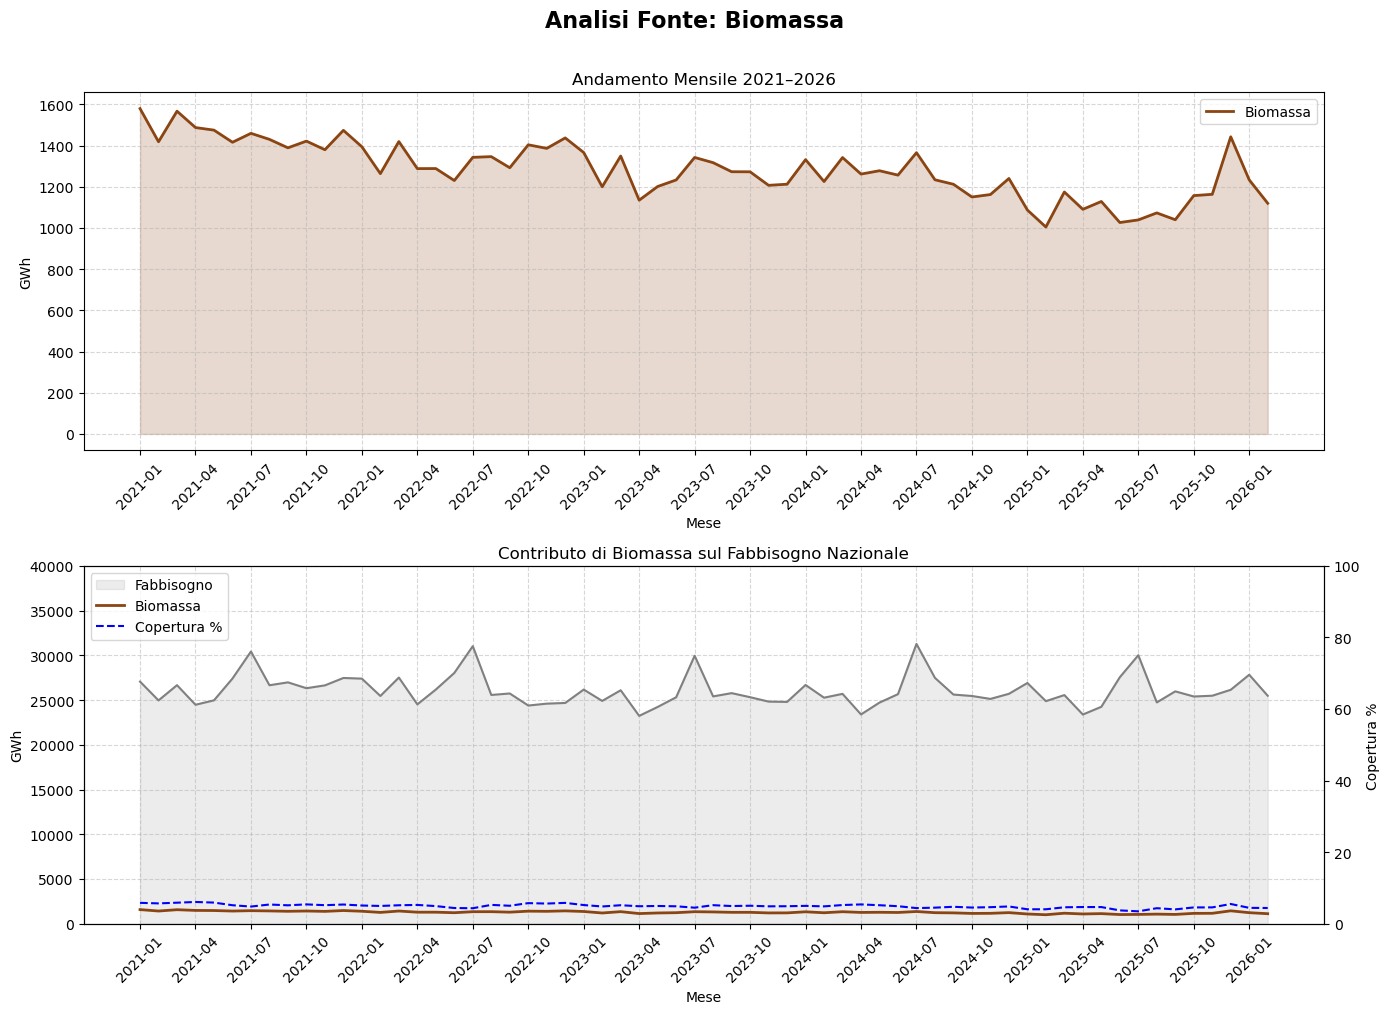

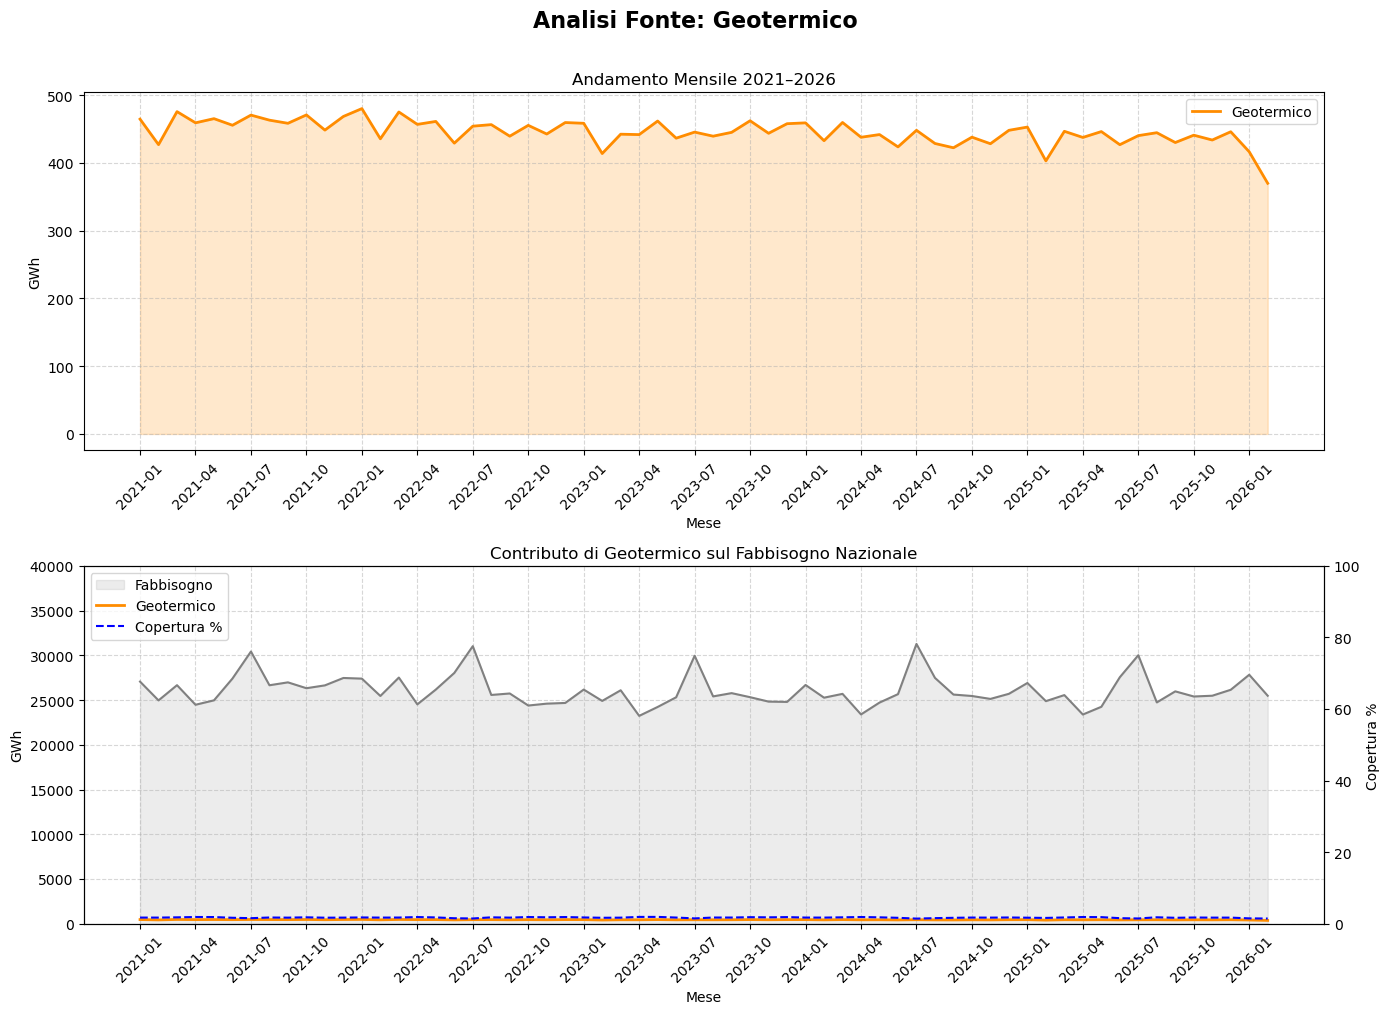

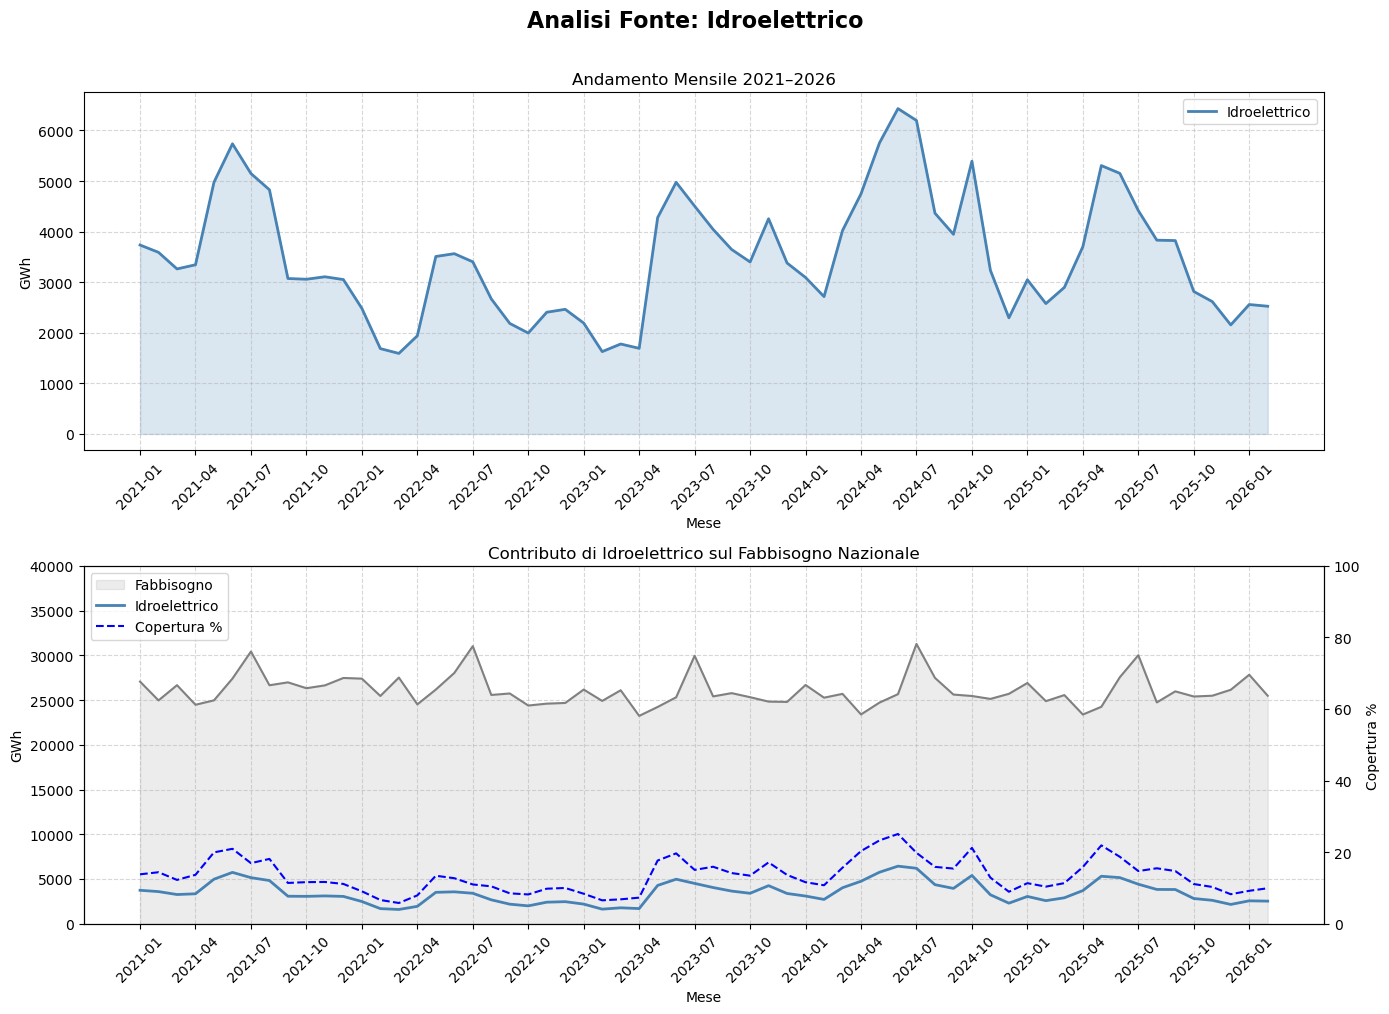

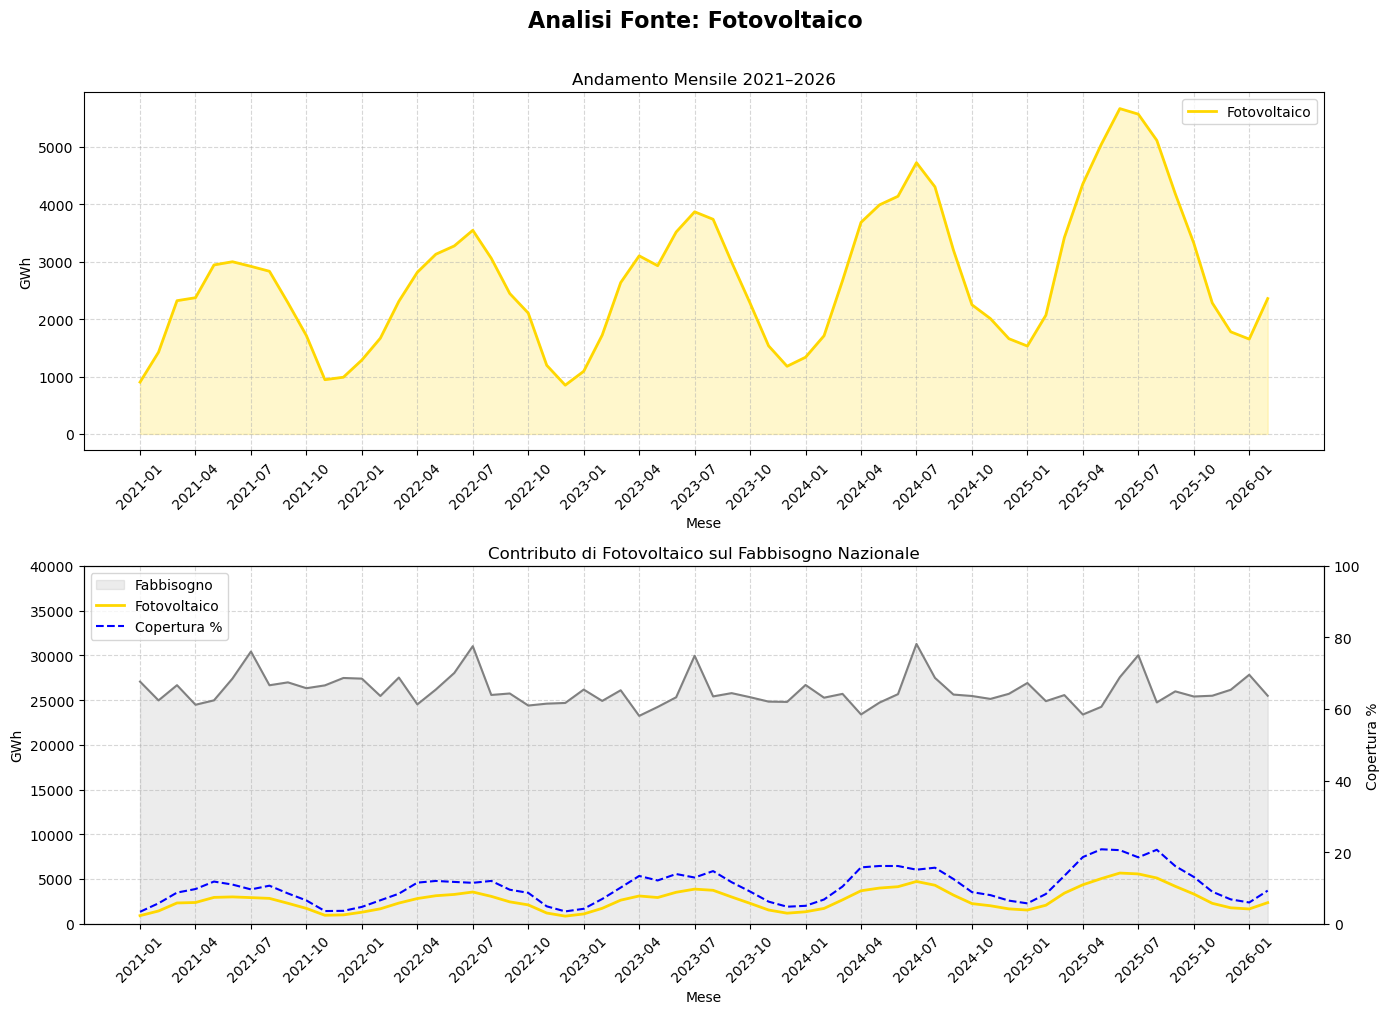

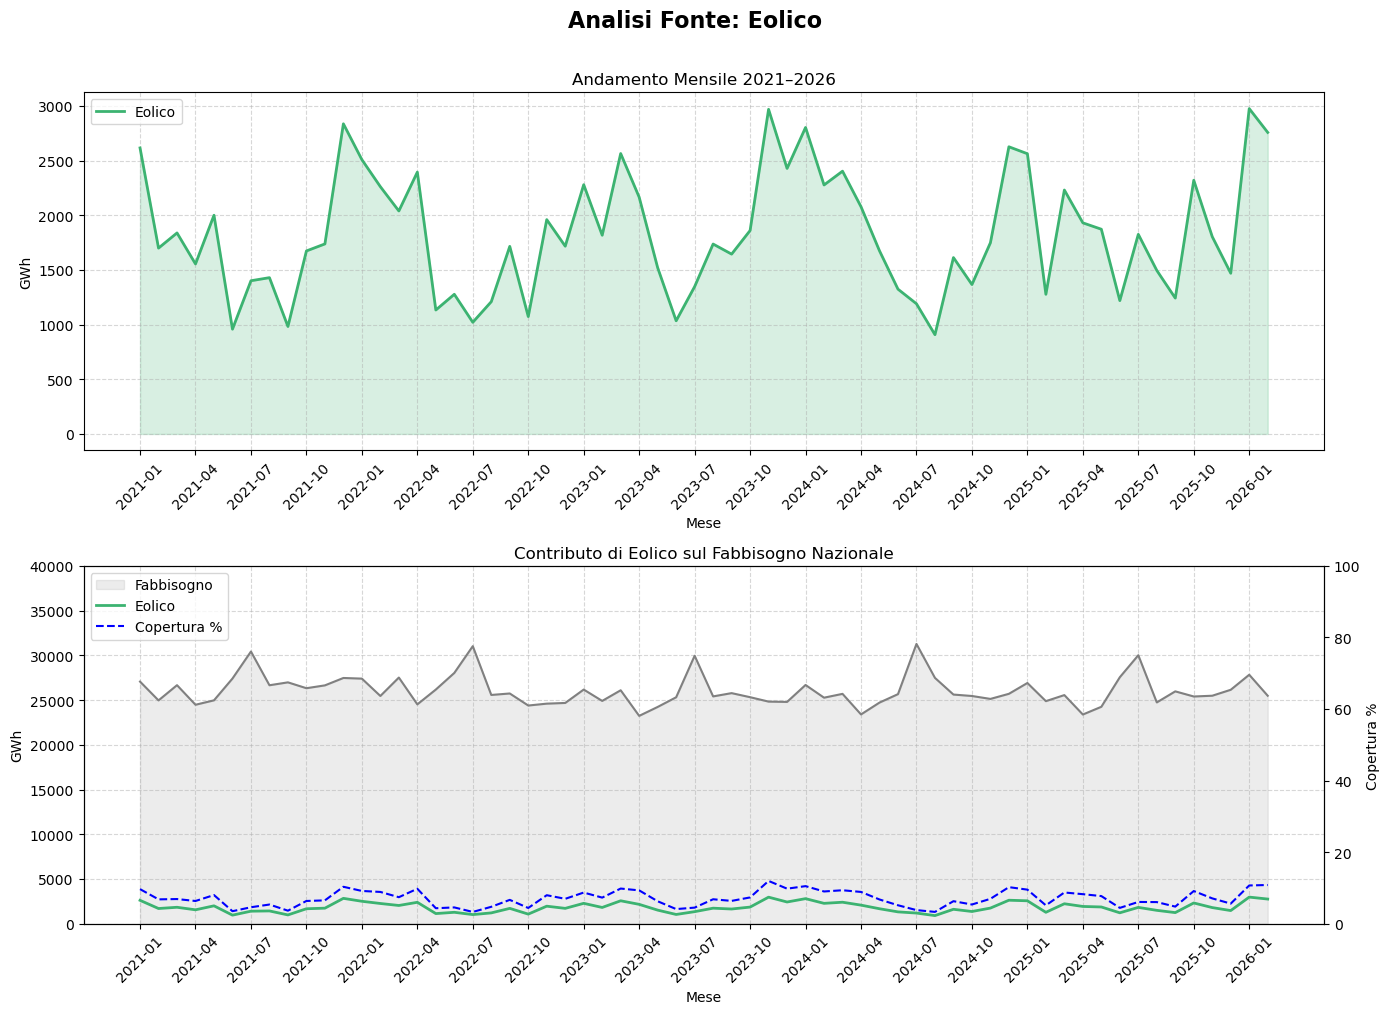

✅ PDF salvato: Analisi_per_Fonte.pdf


In [12]:
with PdfPages('Analisi_per_Fonte.pdf') as pdf:

    for fonte, info in fonti.items():
        colore = info['colore']
        nome   = info['nome']

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
        fig.suptitle(f'Analisi Fonte: {nome}', fontsize=16, fontweight='bold', y=1.01)

        # ── GRAFICO 1: Andamento mensile ──────────────────────────
        ax1.plot(df['Date'], df[fonte], color=colore, linewidth=2, label=nome)
        ax1.fill_between(df['Date'], df[fonte], alpha=0.2, color=colore)
        ax1.set_title('Andamento Mensile 2021–2026')
        ax1.set_ylabel('GWh')
        ax1.set_xlabel('Mese')
        ax1.tick_params(axis='x', rotation=45)
        ax1.set_xticks(df['Date'][::3])
        ax1.grid(True, linestyle='--', alpha=0.5)
        ax1.legend()

        # ── GRAFICO 2: Confronto con fabbisogno ───────────────────
        df[f'Copertura_{fonte}_%'] = (df[fonte] / df['Fabbisogno_GWh']) * 100

        ax2_twin = ax2.twinx()

        ax2.fill_between(df['Date'], df['Fabbisogno_GWh'], alpha=0.15, color='gray', label='Fabbisogno')
        ax2.plot(df['Date'], df['Fabbisogno_GWh'], color='gray', linewidth=1.5)
        ax2.plot(df['Date'], df[fonte], color=colore, linewidth=2, label=nome)
        ax2.set_ylabel('GWh')
        ax2.set_xlabel('Mese')
        ax2.tick_params(axis='x', rotation=45)
        ax2.set_xticks(df['Date'][::3])
        ax2.set_ylim(0, 40000)
        ax2.grid(True, linestyle='--', alpha=0.5)

        ax2_twin.plot(df['Date'], df[f'Copertura_{fonte}_%'],
                      color='blue', linewidth=1.5, linestyle='--', label='Copertura %')
        ax2_twin.set_ylabel('Copertura %')
        ax2_twin.set_ylim(0, 100)

        ax2.set_title(f'Contributo di {nome} sul Fabbisogno Nazionale')

        lines1, labels1 = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_twin.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.show()
        plt.close()

print("✅ PDF salvato: Analisi_per_Fonte.pdf")

In [8]:
print(df[['Date', 'Biomass', f'Copertura_Biomass_%']].head(5))
print("\nMedia copertura Biomass:", df['Copertura_Biomass_%'].mean())

      Date   Biomass  Copertura_Biomass_%
0  2021-01  1579.200             5.835716
1  2021-02  1418.232             5.681953
2  2021-03  1566.634             5.876093
3  2021-04  1487.184             6.076916
4  2021-05  1474.692             5.906492

Media copertura Biomass: 4.931604979500491
